<a href="https://colab.research.google.com/github/RiaKodo/testbi/blob/main/all%20analyses%20and%20bablock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import requests
import io

# Define the URL of the Excel file
excel_url = 'https://github.com/RiaKodo/testbi/raw/main/alamar_olink%20only.xlsx'

# Send a GET request to the URL to download the file content
response = requests.get(excel_url)

# Check if the request was successful
if response.status_code == 200:
    # Read the content into a BytesIO object
    excel_data = io.BytesIO(response.content)

    # Read the Excel file into a pandas DataFrame
    df = pd.read_excel(excel_data)

    # Display the first 5 rows of the DataFrame
    print("Excel file loaded successfully!")
    display(df.head())
else:
    print(f"Failed to download the Excel file. Status code: {response.status_code}")
    print("Please check the URL and your internet connection.")

Excel file loaded successfully!


,ALAMAR_ID,ALAMAR_platepos,BIOAX_ID,GROUP,AGE,SEX,CCL11,MCP4,MCP1,CCL3,...,IL7_OLINK,IL10_OLINK,IL13_OLINK,IL17A_OLINK,IL18_OLINK,S100_A12_OLINK,TNF_OLINK,VEGFA_OLINK,IL6_IL10,IL6_IL10_OLINK
0,A_09_504089_Controls,A_09,504089,CON,43,Female,13.987254,13.451684,12.106203,8.640543,...,1.31139,1.52949,-1.47114,0.10145,8.15053,1.32965,2.63847,11.61742,-5.909322,-0.06233
1,A_10_504086_Controls,A_10,504086,CON,47,Male,15.186008,14.534820,13.019454,9.060234,...,1.34686,1.15437,-0.58082,-0.14630,7.82418,2.54657,2.56944,11.40506,-2.917068,1.50379
2,A_11_505260_Controls,A_11,505260,CON,37,Male,14.770383,14.551773,13.546072,8.323090,...,1.01801,0.67558,-1.37315,-0.40920,8.25509,1.53180,2.23006,11.59180,-4.712135,0.13694
3,B_01_505496_Controls,B_01,505496,CON,18,Male,14.012306,14.197147,12.387656,8.962086,...,1.85030,1.34336,-0.47112,0.75646,8.44195,6.41803,3.28226,11.80627,-3.876421,0.78121
4,B_04_505402_Controls,B_04,505402,CON,67,Male,15.374340,14.397764,13.443584,10.053066,...,0.59143,1.98544,-0.88305,-0.82783,8.42969,0.88071,3.75460,11.37357,-3.751047,0.75354


In [ ]:
df['male'] = (df['SEX'] == 'Male').astype(int)
df['female'] = (df['SEX'] == 'Female').astype(int)

print("DataFrame with 'male' and 'female' columns added:")
display(df.head())

DataFrame with 'male' and 'female' columns added:


,ALAMAR_ID,ALAMAR_platepos,BIOAX_ID,GROUP,AGE,SEX,CCL11,MCP4,MCP1,CCL3,...,IL13_OLINK,IL17A_OLINK,IL18_OLINK,S100_A12_OLINK,TNF_OLINK,VEGFA_OLINK,IL6_IL10,IL6_IL10_OLINK,male,female
0,A_09_504089_Controls,A_09,504089,CON,43,Female,13.987254,13.451684,12.106203,8.640543,...,-1.47114,0.10145,8.15053,1.32965,2.63847,11.61742,-5.909322,-0.06233,0,1
1,A_10_504086_Controls,A_10,504086,CON,47,Male,15.186008,14.534820,13.019454,9.060234,...,-0.58082,-0.14630,7.82418,2.54657,2.56944,11.40506,-2.917068,1.50379,1,0
2,A_11_505260_Controls,A_11,505260,CON,37,Male,14.770383,14.551773,13.546072,8.323090,...,-1.37315,-0.40920,8.25509,1.53180,2.23006,11.59180,-4.712135,0.13694,1,0
3,B_01_505496_Controls,B_01,505496,CON,18,Male,14.012306,14.197147,12.387656,8.962086,...,-0.47112,0.75646,8.44195,6.41803,3.28226,11.80627,-3.876421,0.78121,1,0
4,B_04_505402_Controls,B_04,505402,CON,67,Male,15.374340,14.397764,13.443584,10.053066,...,-0.88305,-0.82783,8.42969,0.88071,3.75460,11.37357,-3.751047,0.75354,1,0


In [ ]:
import pandas as pd

correlation_results = {}

# Identify Olink columns and their base names
olink_columns = [col for col in df.columns if '_OLINK' in col]

for olink_col in olink_columns:
    base_name = olink_col.replace('_OLINK', '')

    # Check if a column with the base name exists in the DataFrame
    if base_name in df.columns:
        # Ensure both columns are numeric, coercing errors (like 'No Data') to NaN
        col1_numeric = pd.to_numeric(df[olink_col], errors='coerce')
        col2_numeric = pd.to_numeric(df[base_name], errors='coerce')

        # Calculate the correlation between the two columns, dropping NaNs for the calculation
        correlation = col1_numeric.corr(col2_numeric)

        # Only store if correlation is not NaN (i.e., there was enough valid data)
        if not pd.isna(correlation):
            correlation_results[f'{base_name} vs {olink_col}'] = correlation

# Display the correlation results
if correlation_results:
    correlation_df = pd.DataFrame(correlation_results.items(), columns=['Column Pair', 'Correlation'])
    print("Correlations between Olink columns and their counterparts:")
    display(correlation_df.sort_values(by='Correlation', ascending=False))
else:
    print("No matching 'OLINK' and non-'OLINK' column pairs found for correlation, or no valid data for calculation.")

Correlations between Olink columns and their counterparts:


,Column Pair,Correlation
13,IL6 vs IL6_OLINK,0.983366
21,IL6_IL10 vs IL6_IL10_OLINK,0.958457
15,IL10 vs IL10_OLINK,0.947461
7,MCP4 vs MCP4_OLINK,0.944982
6,MCP1 vs MCP1_OLINK,0.916961
3,CXCL10 vs CXCL10_OLINK,0.916505
0,CCL3 vs CCL3_OLINK,0.905038
14,IL7 vs IL7_OLINK,0.816816
1,CCL4 vs CCL4_OLINK,0.774379
4,CCL11 vs CCL11_OLINK,0.758026


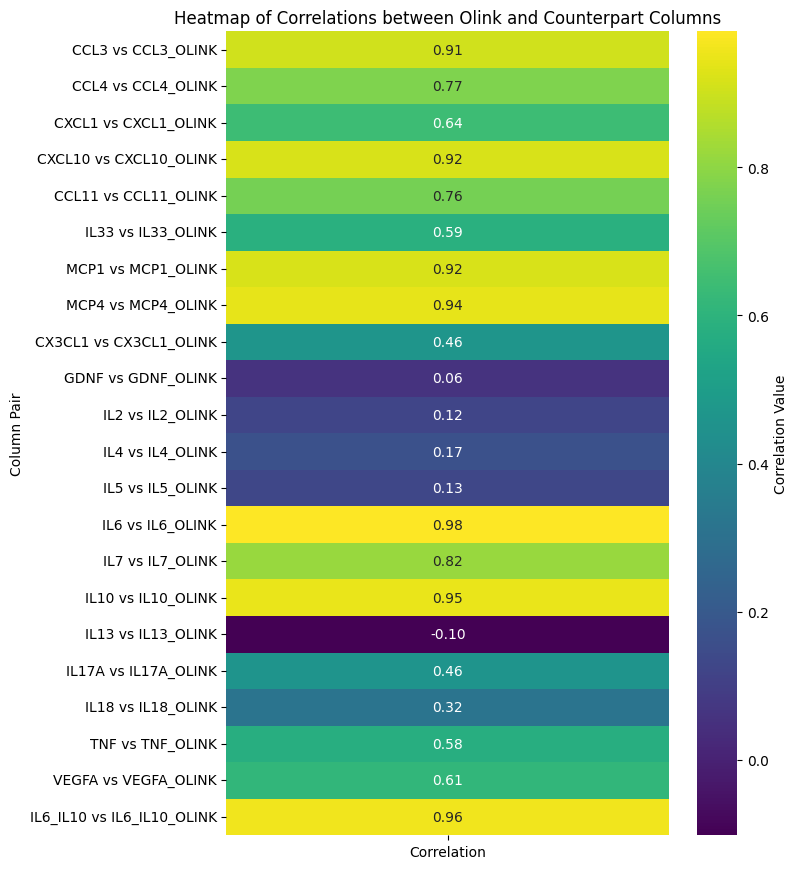

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the 'Column Pair' is set as the index for the heatmap
# and that we are only plotting the 'Correlation' values.
heatmap_data = correlation_df.set_index('Column Pair')

plt.figure(figsize=(8, len(heatmap_data) * 0.4)) # Adjust figure size dynamically based on number of pairs
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".2f", cbar_kws={'label': 'Correlation Value'})
plt.title('Heatmap of Correlations between Olink and Counterpart Columns')
plt.xlabel('') # Remove x-label as there's only one column representing correlation
plt.ylabel('Column Pair')
plt.yticks(rotation=0) # Keep y-labels horizontal for better readability
plt.tight_layout()
plt.show()

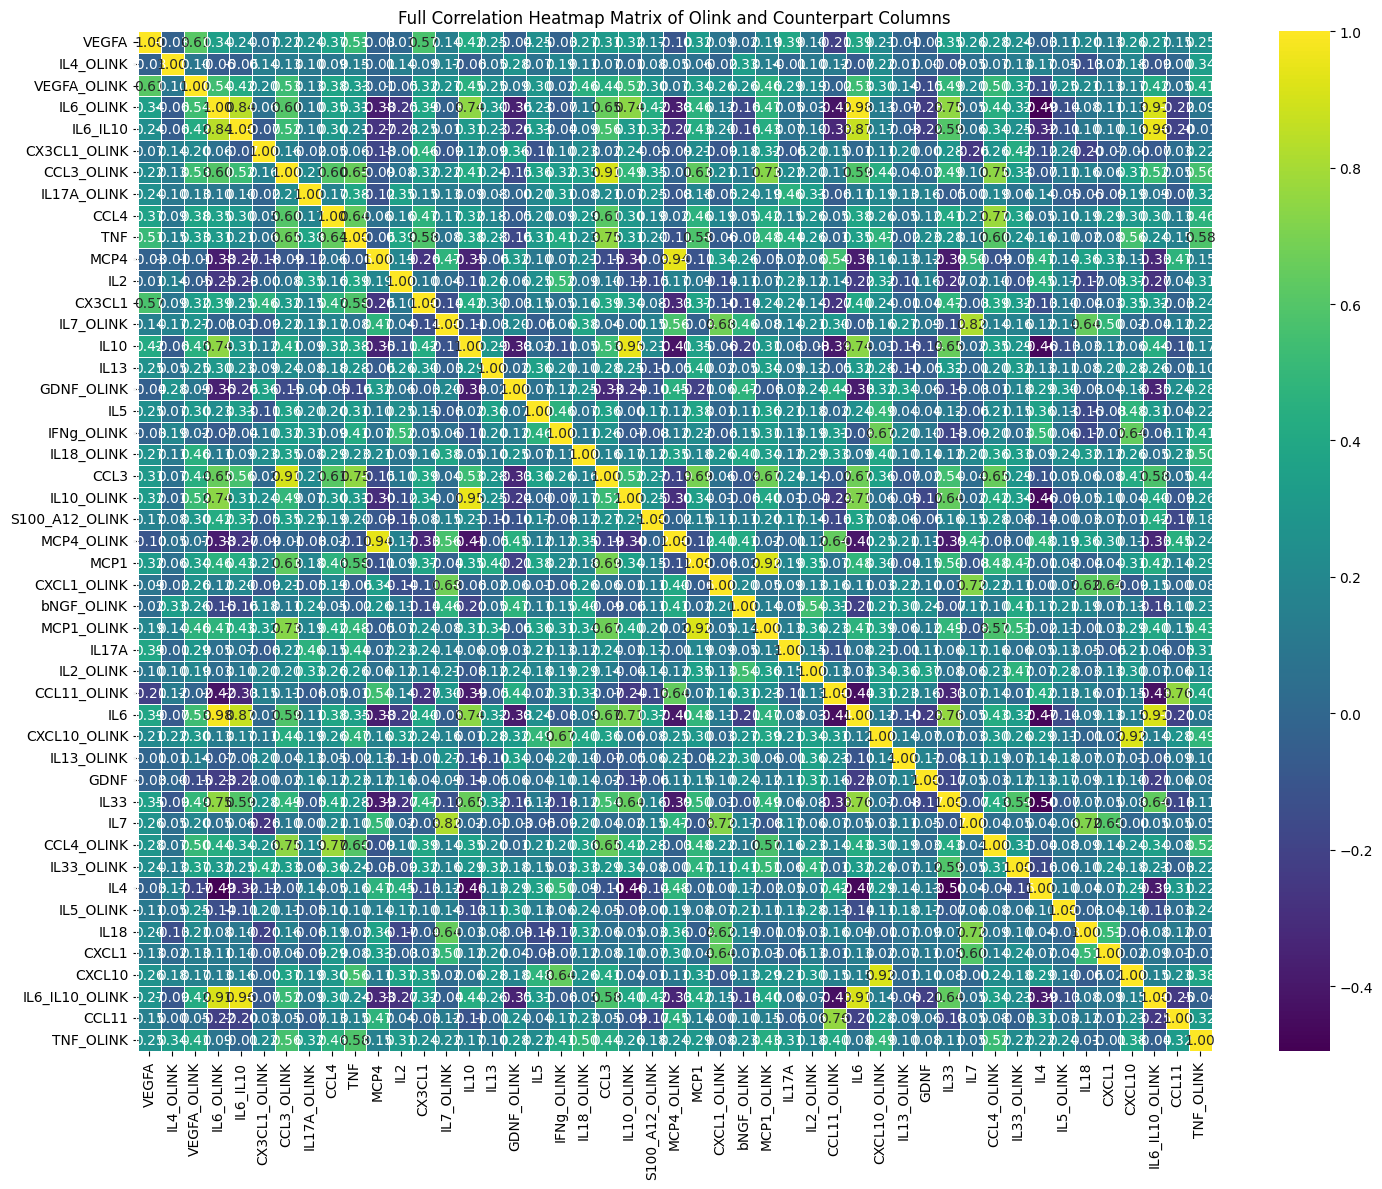

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Identify all 'OLINK' columns
olink_cols = [col for col in df.columns if '_OLINK' in col]

# Identify their corresponding non-'OLINK' columns
base_cols = [col.replace('_OLINK', '') for col in olink_cols if col.replace('_OLINK', '') in df.columns]

# Combine and get unique list of all relevant columns
all_relevant_cols = list(set(olink_cols + base_cols))

# Filter the DataFrame to include only these relevant columns
df_filtered = df[all_relevant_cols].copy()

# Convert all relevant columns to numeric, coercing errors to NaN
for col in df_filtered.columns:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

# Calculate the full correlation matrix
correlation_matrix = df_filtered.corr()

# Plot the correlation heatmap matrix
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Full Correlation Heatmap Matrix of Olink and Counterpart Columns')
plt.tight_layout()
plt.show()

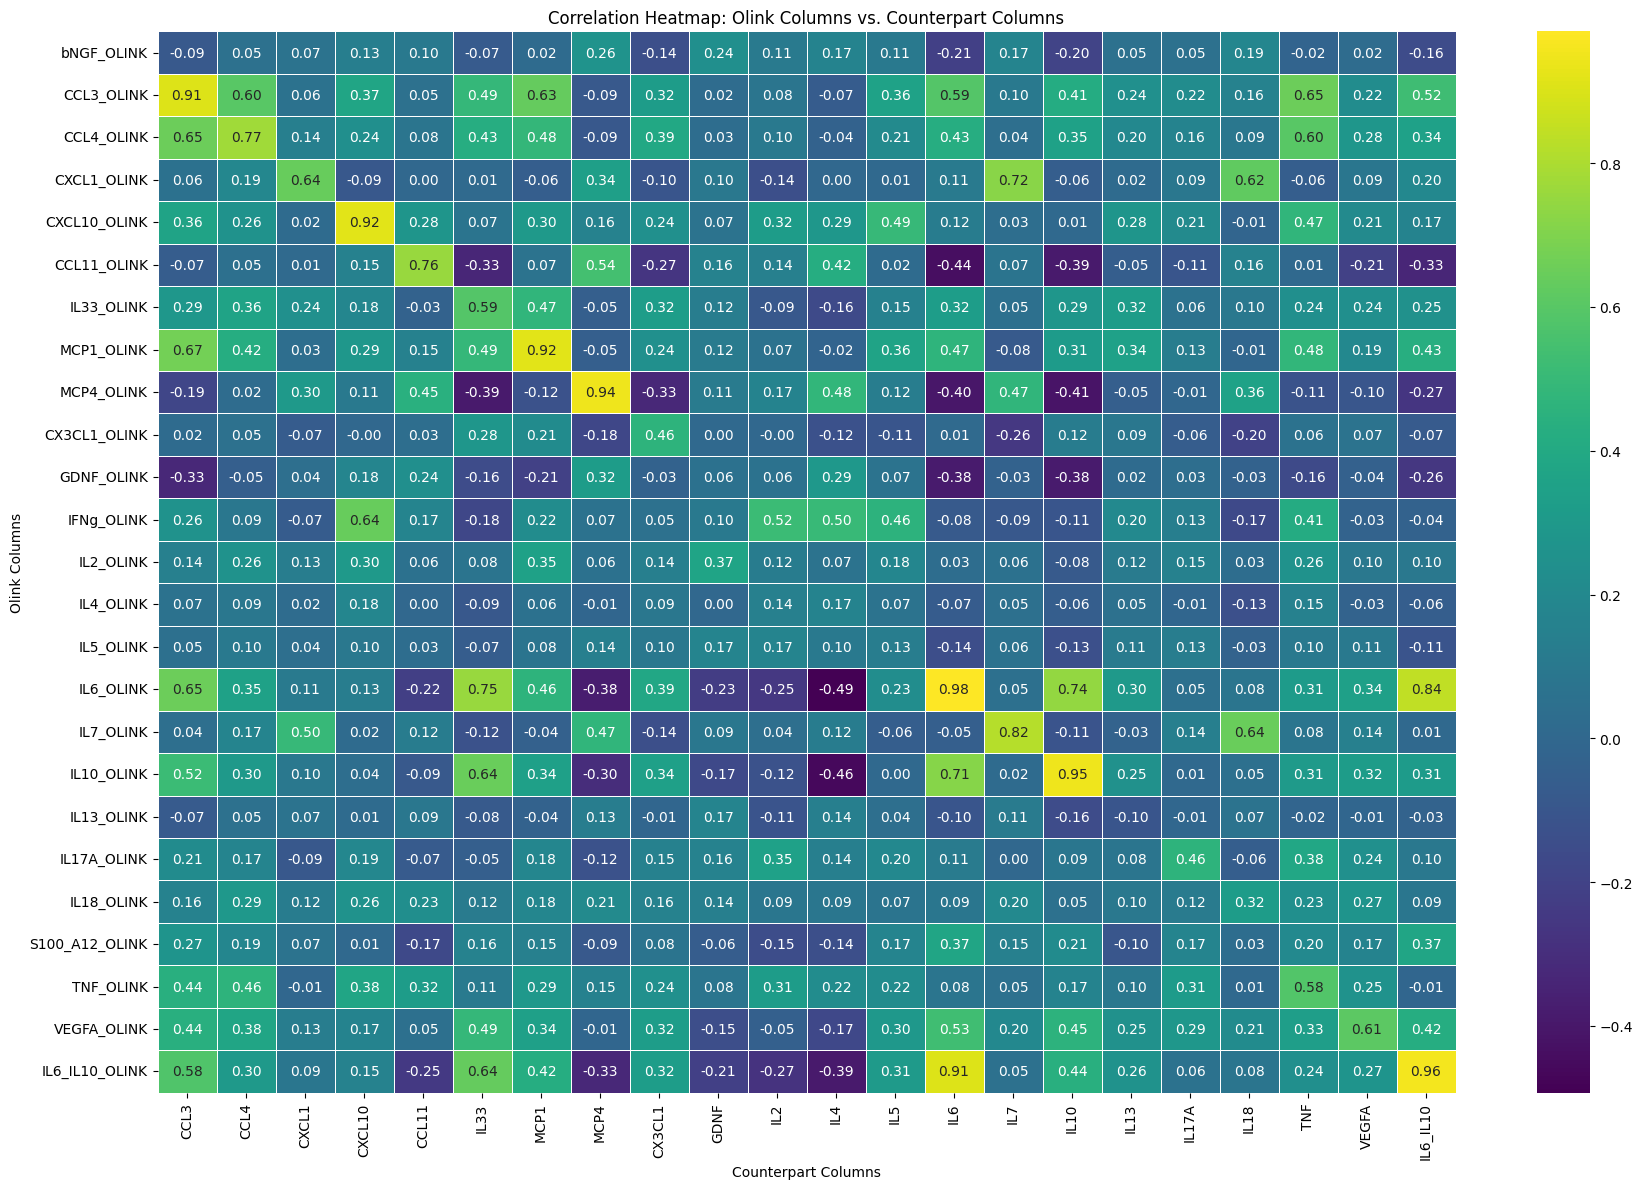

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reuse the identified lists of Olink and base columns from the previous cell
# olink_cols and base_cols are already defined from the previous cell (0c3c4081)

# Create a filtered correlation matrix containing only correlations between olink_cols and base_cols
# The rows will be the Olink columns, and the columns will be the base columns.
filtered_correlation_matrix = correlation_matrix.loc[olink_cols, base_cols]

# Plot the filtered correlation heatmap matrix
plt.figure(figsize=(18, 12))
sns.heatmap(filtered_correlation_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap: Olink Columns vs. Counterpart Columns')
plt.xlabel('Counterpart Columns')
plt.ylabel('Olink Columns')
plt.tight_layout()
plt.show()

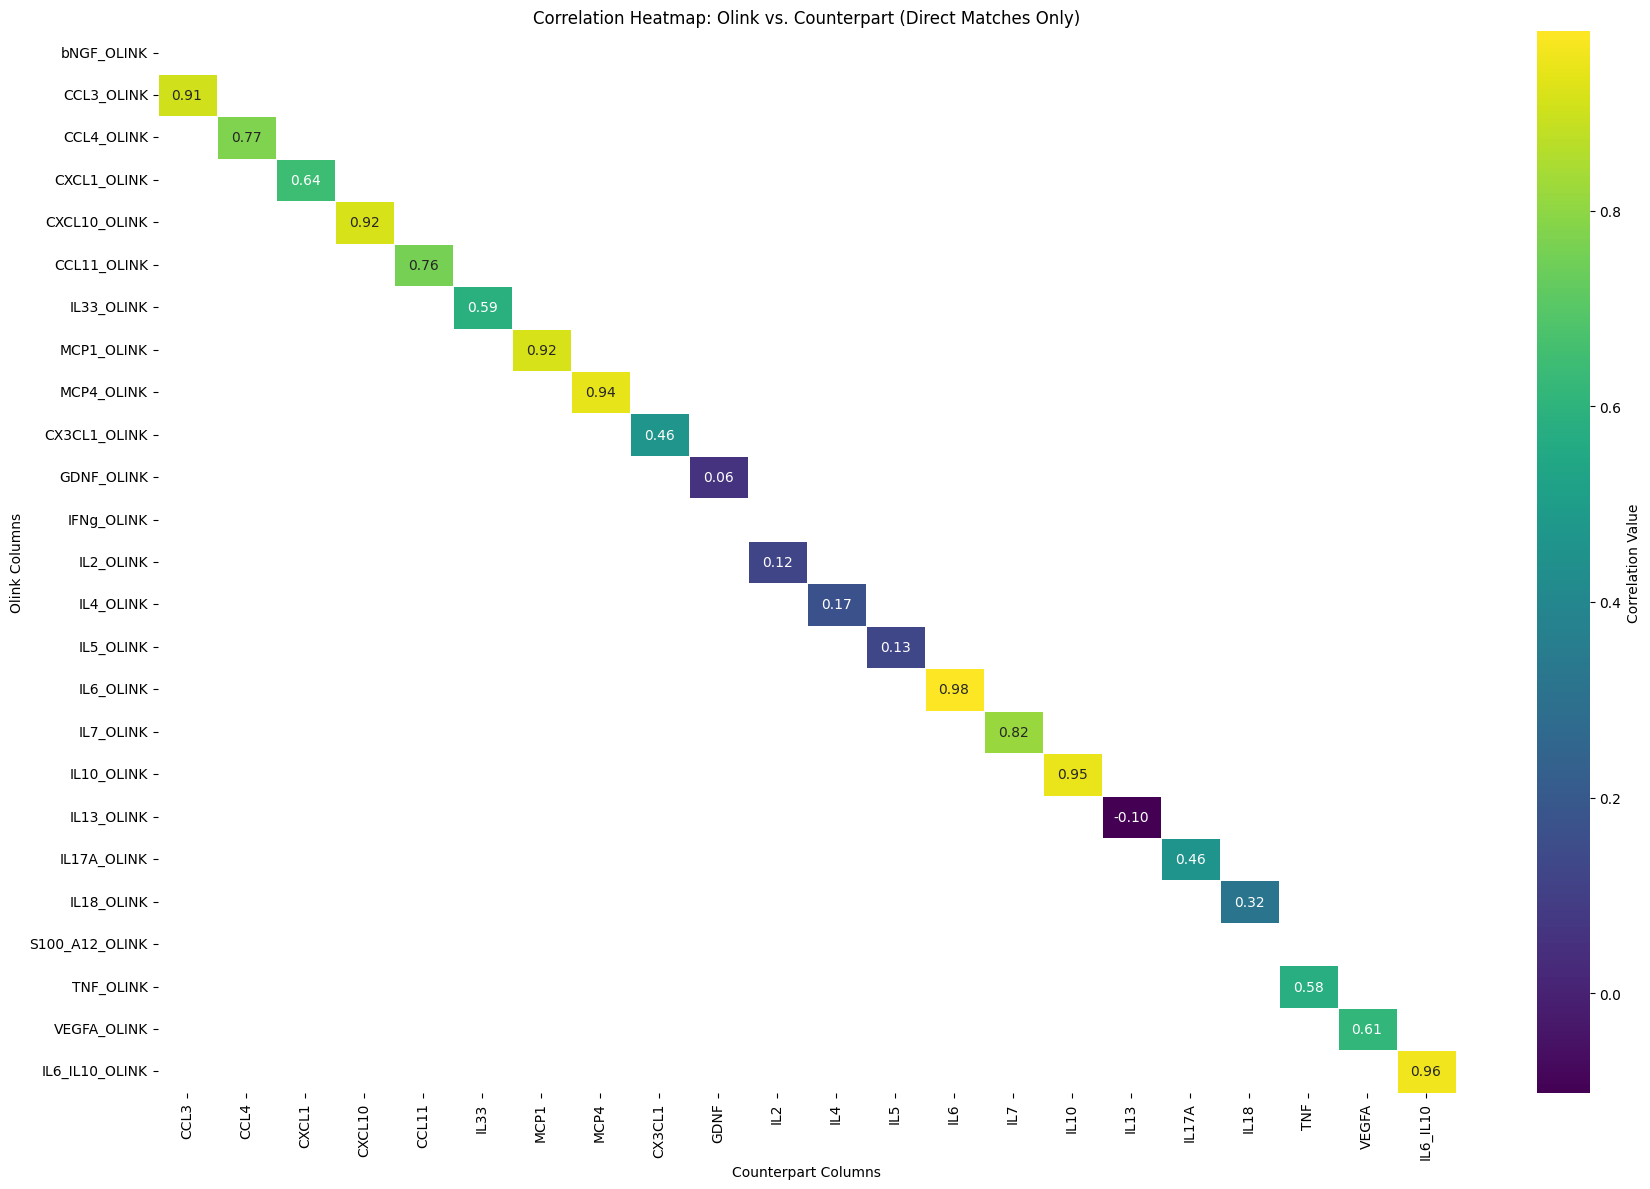

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create an empty DataFrame with the same shape and indices as filtered_correlation_matrix
# This will allow us to selectively populate only the 'same for same' correlations.
diagonal_correlations_matrix = pd.DataFrame(np.nan, index=filtered_correlation_matrix.index, columns=filtered_correlation_matrix.columns)

# Populate the matrix with correlations only where the Olink column matches its base name
for olink_col in filtered_correlation_matrix.index:
    base_name = olink_col.replace('_OLINK', '')
    # Check if the base name exists as a column in the filtered_correlation_matrix
    # (which it should, as base_cols was derived from olink_cols)
    if base_name in filtered_correlation_matrix.columns:
        diagonal_correlations_matrix.loc[olink_col, base_name] = filtered_correlation_matrix.loc[olink_col, base_name]

# Plot the heatmap for these direct matches
plt.figure(figsize=(18, 12)) # Maintain similar size for comparison with previous matrix
sns.heatmap(diagonal_correlations_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Correlation Value'})
plt.title('Correlation Heatmap: Olink vs. Counterpart (Direct Matches Only)')
plt.xlabel('Counterpart Columns')
plt.ylabel('Olink Columns')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Extract non-NaN values from the diagonal_correlations_matrix
# We iterate through the index (Olink columns) and find the corresponding base column
# to get the correlation value.

same_for_same_correlations = []
for olink_col in diagonal_correlations_matrix.index:
    base_name = olink_col.replace('_OLINK', '')
    if base_name in diagonal_correlations_matrix.columns:
        correlation_value = diagonal_correlations_matrix.loc[olink_col, base_name]
        if not pd.isna(correlation_value):
            same_for_same_correlations.append({
                'Column Pair': f'{base_name} vs {olink_col}',
                'Correlation': correlation_value
            })

# Convert to a DataFrame for a clean display
single_line_correlations_df = pd.DataFrame(same_for_same_correlations)

# Display the results, sorted by correlation value for easy review
print("Direct 'Same for Same' Correlations (no gaps):")
display(single_line_correlations_df.sort_values(by='Correlation', ascending=False).reset_index(drop=True))

Direct 'Same for Same' Correlations (no gaps):


,Column Pair,Correlation
0,IL6 vs IL6_OLINK,0.983366
1,IL6_IL10 vs IL6_IL10_OLINK,0.958457
2,IL10 vs IL10_OLINK,0.947461
3,MCP4 vs MCP4_OLINK,0.944982
4,MCP1 vs MCP1_OLINK,0.916961
5,CXCL10 vs CXCL10_OLINK,0.916505
6,CCL3 vs CCL3_OLINK,0.905038
7,IL7 vs IL7_OLINK,0.816816
8,CCL4 vs CCL4_OLINK,0.774379
9,CCL11 vs CCL11_OLINK,0.758026


In [ ]:
import pandas as pd

subgroups = ['CON', 'NTT', 'TBI']

for group_name in subgroups:
    print(f"\n--- Correlations for Group: {group_name} ---")

    # Filter the original DataFrame for the current subgroup
    df_subgroup = df[df['GROUP'] == group_name].copy()

    if df_subgroup.empty:
        print(f"No data found for group {group_name}.")
        continue

    # Identify Olink columns and their base names (reusing logic from previous cells)
    olink_columns_subgroup = [col for col in df_subgroup.columns if '_OLINK' in col]
    correlation_results_subgroup = []

    for olink_col in olink_columns_subgroup:
        base_name = olink_col.replace('_OLINK', '')

        if base_name in df_subgroup.columns:
            # Ensure both columns are numeric, coercing errors to NaN
            col1_numeric = pd.to_numeric(df_subgroup[olink_col], errors='coerce')
            col2_numeric = pd.to_numeric(df_subgroup[base_name], errors='coerce')

            # Calculate the correlation
            correlation = col1_numeric.corr(col2_numeric)

            if not pd.isna(correlation):
                correlation_results_subgroup.append({
                    'Column Pair': f'{base_name} vs {olink_col}',
                    'Correlation': correlation
                })

    if correlation_results_subgroup:
        subgroup_correlations_df = pd.DataFrame(correlation_results_subgroup)
        display(subgroup_correlations_df.sort_values(by='Correlation', ascending=False).reset_index(drop=True))
    else:
        print(f"No matching 'OLINK' and non-'OLINK' column pairs found for correlation in group {group_name}, or no valid data for calculation.")


--- Correlations for Group: CON ---


,Column Pair,Correlation
0,IL6 vs IL6_OLINK,0.961815
1,MCP4 vs MCP4_OLINK,0.945769
2,IL6_IL10 vs IL6_IL10_OLINK,0.929593
3,CXCL10 vs CXCL10_OLINK,0.895124
4,MCP1 vs MCP1_OLINK,0.874557
5,CCL11 vs CCL11_OLINK,0.848797
6,IL10 vs IL10_OLINK,0.843701
7,CCL3 vs CCL3_OLINK,0.820069
8,CCL4 vs CCL4_OLINK,0.789464
9,IL7 vs IL7_OLINK,0.772520



--- Correlations for Group: NTT ---


,Column Pair,Correlation
0,MCP4 vs MCP4_OLINK,0.956561
1,IL10 vs IL10_OLINK,0.944064
2,IL7 vs IL7_OLINK,0.913857
3,MCP1 vs MCP1_OLINK,0.890150
4,IL6 vs IL6_OLINK,0.885515
5,CCL3 vs CCL3_OLINK,0.860210
6,CXCL10 vs CXCL10_OLINK,0.799760
7,IL6_IL10 vs IL6_IL10_OLINK,0.755906
8,CCL11 vs CCL11_OLINK,0.754686
9,VEGFA vs VEGFA_OLINK,0.751473



--- Correlations for Group: TBI ---


,Column Pair,Correlation
0,IL6 vs IL6_OLINK,0.975476
1,IL6_IL10 vs IL6_IL10_OLINK,0.948722
2,IL10 vs IL10_OLINK,0.948704
3,CXCL10 vs CXCL10_OLINK,0.939459
4,MCP4 vs MCP4_OLINK,0.923913
5,MCP1 vs MCP1_OLINK,0.920065
6,CCL3 vs CCL3_OLINK,0.904005
7,CCL4 vs CCL4_OLINK,0.846566
8,IL7 vs IL7_OLINK,0.839292
9,CXCL1 vs CXCL1_OLINK,0.744750


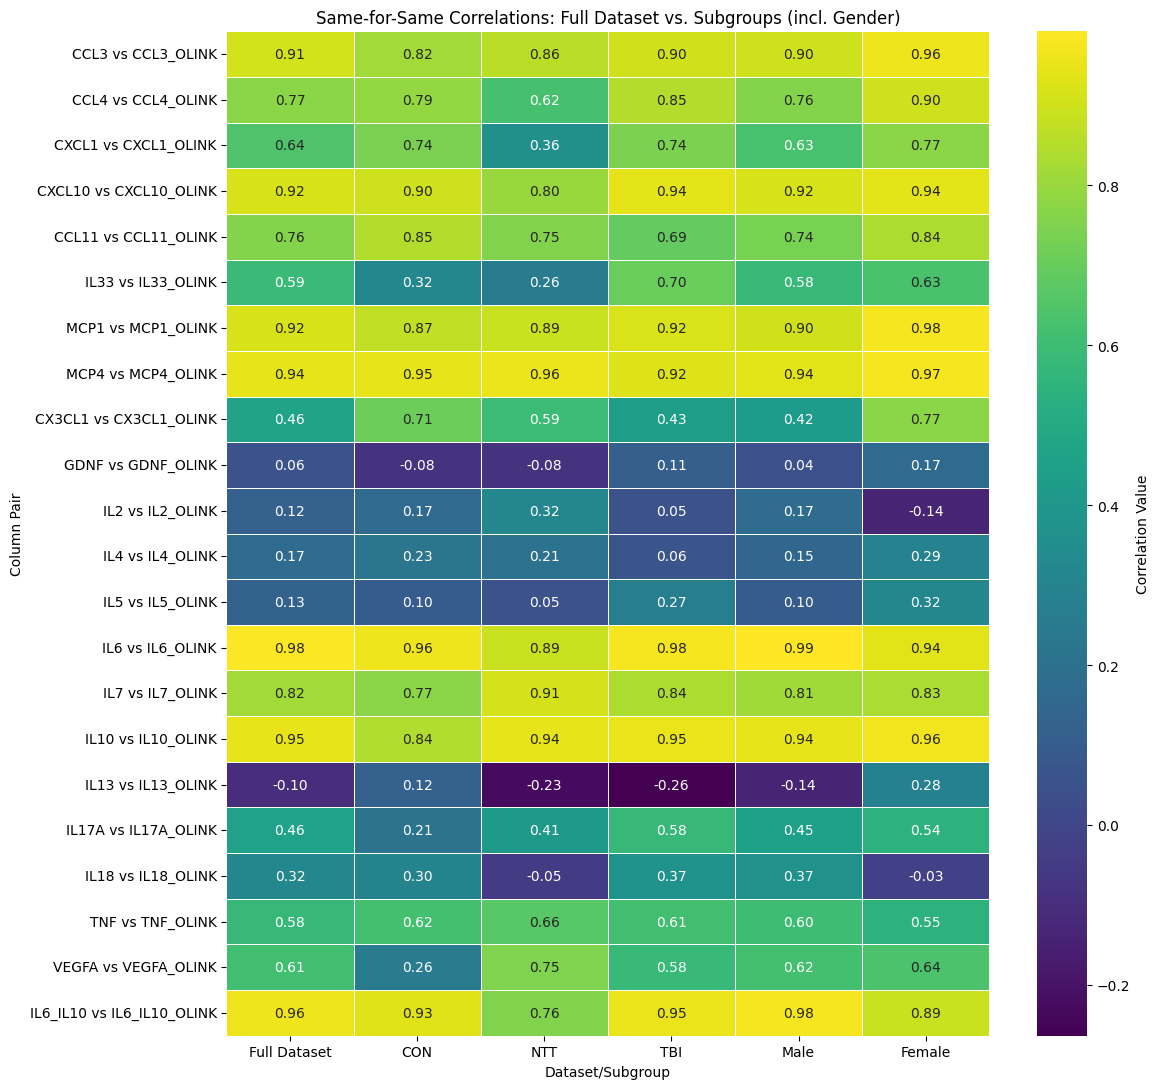

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Prepare full dataset correlations
# The single_line_correlations_df already contains the 'same for same' correlations for the full dataset.
# Let's rename the 'Correlation' column for merging.
full_correlations = single_line_correlations_df.rename(columns={'Correlation': 'Full Dataset'})

# Identify all 'OLINK' columns from the main dataframe `df`
# This list will be used for all subgroup calculations for consistency.
olink_columns_master = [col for col in df.columns if '_OLINK' in col]

# Prepare subgroup correlations
all_subgroup_correlations = {}

# Process existing 'GROUP' categories
group_categories = ['CON', 'NTT', 'TBI']
for group_name in group_categories:
    df_subgroup = df[df['GROUP'] == group_name].copy()

    if df_subgroup.empty:
        print(f"No data found for group {group_name}. Skipping.")
        continue

    correlation_results_subgroup = []
    for olink_col in olink_columns_master:
        base_name = olink_col.replace('_OLINK', '')
        if base_name in df_subgroup.columns:
            col1_numeric = pd.to_numeric(df_subgroup[olink_col], errors='coerce')
            col2_numeric = pd.to_numeric(df_subgroup[base_name], errors='coerce')
            correlation = col1_numeric.corr(col2_numeric)

            if not pd.isna(correlation):
                correlation_results_subgroup.append({
                    'Column Pair': f'{base_name} vs {olink_col}',
                    'Correlation': correlation
                })

    if correlation_results_subgroup:
        subgroup_df = pd.DataFrame(correlation_results_subgroup)
        all_subgroup_correlations[group_name] = subgroup_df.rename(columns={'Correlation': group_name})

# Process 'Male' subgroup
df_male = df[df['male'] == 1].copy()
if not df_male.empty:
    correlation_results_male = []
    for olink_col in olink_columns_master:
        base_name = olink_col.replace('_OLINK', '')
        if base_name in df_male.columns:
            col1_numeric = pd.to_numeric(df_male[olink_col], errors='coerce')
            col2_numeric = pd.to_numeric(df_male[base_name], errors='coerce')
            correlation = col1_numeric.corr(col2_numeric)
            if not pd.isna(correlation):
                correlation_results_male.append({'Column Pair': f'{base_name} vs {olink_col}', 'Correlation': correlation})
    if correlation_results_male:
        male_df = pd.DataFrame(correlation_results_male)
        all_subgroup_correlations['Male'] = male_df.rename(columns={'Correlation': 'Male'})

# Process 'Female' subgroup
df_female = df[df['female'] == 1].copy()
if not df_female.empty:
    correlation_results_female = []
    for olink_col in olink_columns_master:
        base_name = olink_col.replace('_OLINK', '')
        if base_name in df_female.columns:
            col1_numeric = pd.to_numeric(df_female[olink_col], errors='coerce')
            col2_numeric = pd.to_numeric(df_female[base_name], errors='coerce')
            correlation = col1_numeric.corr(col2_numeric)
            if not pd.isna(correlation):
                correlation_results_female.append({'Column Pair': f'{base_name} vs {olink_col}', 'Correlation': correlation})
    if correlation_results_female:
        female_df = pd.DataFrame(correlation_results_female)
        all_subgroup_correlations['Female'] = female_df.rename(columns={'Correlation': 'Female'})


# Merge all correlation DataFrames
merged_correlations = full_correlations
for group_name, subgroup_df in all_subgroup_correlations.items():
    merged_correlations = pd.merge(merged_correlations, subgroup_df, on='Column Pair', how='left')

# Set 'Column Pair' as index for the heatmap
merged_correlations = merged_correlations.set_index('Column Pair')

# Plot the comparative heatmap
plt.figure(figsize=(12, len(merged_correlations) * 0.5)) # Adjust figure size dynamically
sns.heatmap(merged_correlations, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Correlation Value'})
plt.title('Same-for-Same Correlations: Full Dataset vs. Subgroups (incl. Gender)')
plt.xlabel('Dataset/Subgroup')
plt.ylabel('Column Pair')
plt.yticks(rotation=0) # Keep y-labels horizontal for better readability
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def lins_concordance_coefficient(col1, col2):
    """Calculates Lin's Concordance Correlation Coefficient."""
    # Drop NaN values for calculation
    common_indices = col1.dropna().index.intersection(col2.dropna().index)
    if len(common_indices) < 2: # Need at least 2 data points for meaningful calculation
        return np.nan

    col1 = col1.loc[common_indices]
    col2 = col2.loc[common_indices]

    mean_col1 = col1.mean()
    mean_col2 = col2.mean()
    var_col1 = col1.var(ddof=1) # Use ddof=1 for sample variance
    var_col2 = col2.var(ddof=1)
    cov = col1.cov(col2, ddof=1) # Use ddof=1 for sample covariance

    if (var_col1 == 0 and var_col2 == 0) or (pd.isna(var_col1) and pd.isna(var_col2)):
        # Handle cases where one or both variables have zero variance, return 1 if perfectly equal, else NaN
        if np.all(col1 == col2):
            return 1.0
        else:
            return np.nan

    numerator = 2 * cov
    denominator = var_col1 + var_col2 + (mean_col1 - mean_col2)**2

    if denominator == 0:
        return np.nan # Avoid division by zero

    return numerator / denominator


# Prepare full dataset concordance
full_concordance_results = []
for olink_col in olink_columns_master:
    base_name = olink_col.replace('_OLINK', '')
    if base_name in df.columns:
        col1_numeric = pd.to_numeric(df[olink_col], errors='coerce')
        col2_numeric = pd.to_numeric(df[base_name], errors='coerce')
        ccc = lins_concordance_coefficient(col1_numeric, col2_numeric)
        if not pd.isna(ccc):
            full_concordance_results.append({
                'Column Pair': f'{base_name} vs {olink_col}',
                'CCC': ccc
            })
full_concordance_df = pd.DataFrame(full_concordance_results).rename(columns={'CCC': 'Full Dataset'})

# Prepare subgroup concordance
all_subgroup_concordance = {}

# Process existing 'GROUP' categories
group_categories = ['CON', 'NTT', 'TBI']
for group_name in group_categories:
    df_subgroup = df[df['GROUP'] == group_name].copy()

    if df_subgroup.empty:
        print(f"No data found for group {group_name}. Skipping CCC calculation.")
        continue

    subgroup_ccc_results = []
    for olink_col in olink_columns_master:
        base_name = olink_col.replace('_OLINK', '')
        if base_name in df_subgroup.columns:
            col1_numeric = pd.to_numeric(df_subgroup[olink_col], errors='coerce')
            col2_numeric = pd.to_numeric(df_subgroup[base_name], errors='coerce')
            ccc = lins_concordance_coefficient(col1_numeric, col2_numeric)
            if not pd.isna(ccc):
                subgroup_ccc_results.append({'Column Pair': f'{base_name} vs {olink_col}', 'CCC': ccc})

    if subgroup_ccc_results:
        subgroup_df = pd.DataFrame(subgroup_ccc_results)
        all_subgroup_concordance[group_name] = subgroup_df.rename(columns={'CCC': group_name})

# Process 'Male' subgroup
df_male_ccc = df[df['male'] == 1].copy()
if not df_male_ccc.empty:
    ccc_results_male = []
    for olink_col in olink_columns_master:
        base_name = olink_col.replace('_OLINK', '')
        if base_name in df_male_ccc.columns:
            col1_numeric = pd.to_numeric(df_male_ccc[olink_col], errors='coerce')
            col2_numeric = pd.to_numeric(df_male_ccc[base_name], errors='coerce')
            ccc = lins_concordance_coefficient(col1_numeric, col2_numeric)
            if not pd.isna(ccc):
                ccc_results_male.append({'Column Pair': f'{base_name} vs {olink_col}', 'CCC': ccc})
    if ccc_results_male:
        male_ccc_df = pd.DataFrame(ccc_results_male)
        all_subgroup_concordance['Male'] = male_ccc_df.rename(columns={'CCC': 'Male'})

# Process 'Female' subgroup
df_female_ccc = df[df['female'] == 1].copy()
if not df_female_ccc.empty:
    ccc_results_female = []
    for olink_col in olink_columns_master:
        base_name = olink_col.replace('_OLINK', '')
        if base_name in df_female_ccc.columns:
            col1_numeric = pd.to_numeric(df_female_ccc[olink_col], errors='coerce')
            col2_numeric = pd.to_numeric(df_female_ccc[base_name], errors='coerce')
            ccc = lins_concordance_coefficient(col1_numeric, col2_numeric)
            if not pd.isna(ccc):
                ccc_results_female.append({'Column Pair': f'{base_name} vs {olink_col}', 'CCC': ccc})
    if ccc_results_female:
        female_ccc_df = pd.DataFrame(ccc_results_female)
        all_subgroup_concordance['Female'] = female_ccc_df.rename(columns={'CCC': 'Female'})

# Merge all concordance DataFrames
merged_concordance = full_concordance_df
for group_name, subgroup_df in all_subgroup_concordance.items():
    merged_concordance = pd.merge(merged_concordance, subgroup_df, on='Column Pair', how='left')

# Display the merged concordance results
print("Lin's Concordance Correlation Coefficients (CCC): Full Dataset vs. Subgroups")
display(merged_concordance.set_index('Column Pair').sort_values(by='Full Dataset', ascending=False))

Lin's Concordance Correlation Coefficients (CCC): Full Dataset vs. Subgroups


,Full Dataset,CON,NTT,TBI,Male,Female
Column Pair,,,,,,
MCP4 vs MCP4_OLINK,0.771579,0.790721,0.772798,0.715215,0.749803,0.787828
IL6 vs IL6_OLINK,0.358172,0.062064,0.161153,0.177464,0.355565,0.371430
MCP1 vs MCP1_OLINK,0.313068,0.135739,0.251252,0.363917,0.283677,0.482868
IL6_IL10 vs IL6_IL10_OLINK,0.256324,0.082919,0.096136,0.119673,0.250733,0.284450
CXCL1 vs CXCL1_OLINK,0.065051,0.058997,0.041032,0.077987,0.066320,0.049006
CCL3 vs CCL3_OLINK,0.061367,0.027966,0.029419,0.068987,0.060802,0.069809
CCL4 vs CCL4_OLINK,0.055795,0.028512,0.058906,0.056329,0.055547,0.062066
CXCL10 vs CXCL10_OLINK,0.037970,0.022979,0.015059,0.060591,0.040921,0.022627
IL10 vs IL10_OLINK,0.033630,0.013050,0.017857,0.034848,0.030713,0.052089


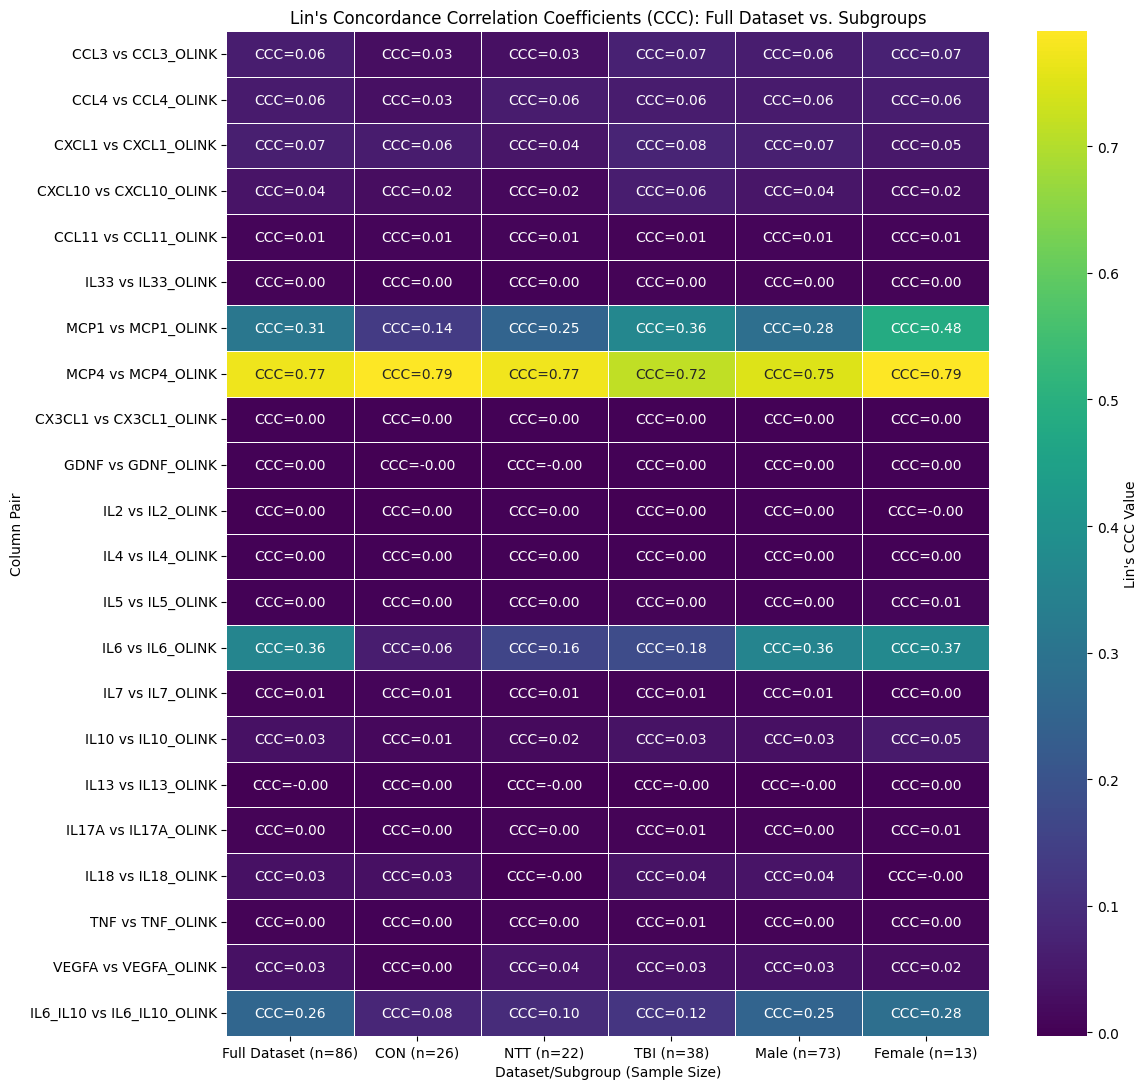

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Column Pair' is the index for plotting
heatmap_concordance_data = merged_concordance.set_index('Column Pair')

# --- Create Custom Annotation Strings for Concordance Heatmap ---
# This will be a 2D array of strings to pass to annot=True
concordance_annotations = np.full(heatmap_concordance_data.shape, '', dtype=object)

for i in range(heatmap_concordance_data.shape[0]):
    for j in range(heatmap_concordance_data.shape[1]):
        ccc_val = heatmap_concordance_data.iloc[i, j]
        # n_val is no longer part of the individual cell annotation, it will be in xticklabels

        if pd.isna(ccc_val):
            concordance_annotations[i, j] = 'N/A'
        else:
            concordance_annotations[i, j] = f"CCC={ccc_val:.2f}"

# Create new x-axis labels with (n=sample_size)
# Reusing n_heatmap_data generated previously, assuming it aligns by column name
concordance_new_xticklabels = []
for col_name in heatmap_concordance_data.columns:
    if col_name in n_heatmap_data.columns:
        total_n_for_group = n_heatmap_data[col_name].iloc[0] if not n_heatmap_data[col_name].empty else 0
        concordance_new_xticklabels.append(f"{col_name} (n={int(total_n_for_group)})")
    else:
        concordance_new_xticklabels.append(col_name) # Fallback if group not found in n_heatmap_data


plt.figure(figsize=(12, len(heatmap_concordance_data) * 0.5)) # Adjust figure size dynamically
sns.heatmap(heatmap_concordance_data,
            annot=concordance_annotations,
            fmt='', # Use empty format string because annotations are pre-formatted
            cmap='viridis',
            linewidths=.5,
            cbar_kws={'label': "Lin's CCC Value"},
            xticklabels=concordance_new_xticklabels)

plt.title("Lin's Concordance Correlation Coefficients (CCC): Full Dataset vs. Subgroups")
plt.xlabel('Dataset/Subgroup (Sample Size)')
plt.ylabel('Column Pair')
plt.yticks(rotation=0) # Keep y-labels horizontal for better readability
plt.tight_layout()
plt.show()

In [ ]:
import scipy.stats

def calculate_pearson_rp(col1, col2):
    """Calculates Pearson correlation coefficient (r) and p-value, handling NaNs."""
    # Drop NaN values for calculation, ensuring common indices
    common_indices = col1.dropna().index.intersection(col2.dropna().index)
    if len(common_indices) < 2: # Need at least 2 data points for meaningful calculation
        return np.nan, np.nan

    col1 = col1.loc[common_indices]
    col2 = col2.loc[common_indices]

    # Check for zero variance
    if col1.std() == 0 or col2.std() == 0:
        return np.nan, np.nan # Cannot calculate correlation if one variable is constant

    r, p = scipy.stats.pearsonr(col1, col2)
    return r, p

In [ ]:
all_rp_results = []

# Full Dataset
for olink_col in olink_columns_master:
    base_name = olink_col.replace('_OLINK', '')
    if base_name in df.columns:
        col1_numeric = pd.to_numeric(df[olink_col], errors='coerce')
        col2_numeric = pd.to_numeric(df[base_name], errors='coerce')
        r, p = calculate_pearson_rp(col1_numeric, col2_numeric)
        if not pd.isna(r):
            all_rp_results.append({
                'Column Pair': f'{base_name} vs {olink_col}',
                'Full Dataset_r': r,
                'Full Dataset_p': p
            })
rp_df = pd.DataFrame(all_rp_results)

# Subgroups
group_categories_with_gender = ['CON', 'NTT', 'TBI', 'Male', 'Female']

for group_name in group_categories_with_gender:
    if group_name == 'Male':
        df_subgroup = df[df['male'] == 1].copy()
    elif group_name == 'Female':
        df_subgroup = df[df['female'] == 1].copy()
    else: # CON, NTT, TBI
        df_subgroup = df[df['GROUP'] == group_name].copy()

    if df_subgroup.empty:
        print(f"No data found for group {group_name}. Skipping R and P-value calculation.")
        continue

    subgroup_rp_results = []
    for olink_col in olink_columns_master:
        base_name = olink_col.replace('_OLINK', '')
        if base_name in df_subgroup.columns:
            col1_numeric = pd.to_numeric(df_subgroup[olink_col], errors='coerce')
            col2_numeric = pd.to_numeric(df_subgroup[base_name], errors='coerce')
            r, p = calculate_pearson_rp(col1_numeric, col2_numeric)
            if not pd.isna(r):
                subgroup_rp_results.append({
                    'Column Pair': f'{base_name} vs {olink_col}',
                    f'{group_name}_r': r,
                    f'{group_name}_p': p
                })

    if subgroup_rp_results:
        subgroup_rp_df = pd.DataFrame(subgroup_rp_results)
        rp_df = pd.merge(rp_df, subgroup_rp_df, on='Column Pair', how='left')

# Display the merged r and p values
print("Pearson Correlation (r) and p-values (p): Full Dataset vs. Subgroups")
display(rp_df.set_index('Column Pair').sort_values(by='Full Dataset_r', ascending=False))

Pearson Correlation (r) and p-values (p): Full Dataset vs. Subgroups


,Full Dataset_r,Full Dataset_p,CON_r,CON_p,NTT_r,NTT_p,TBI_r,TBI_p,Male_r,Male_p,Female_r,Female_p
Column Pair,,,,,,,,,,,,
IL6 vs IL6_OLINK,0.983366,5.227657e-64,0.961815,5.217000e-15,0.885515,4.318041e-08,0.975476,2.922683e-25,0.992504,1.457897e-66,0.937663,2.218089e-06
IL6_IL10 vs IL6_IL10_OLINK,0.958457,1.562578e-47,0.929593,6.814081e-12,0.755906,4.723963e-05,0.948722,1.369621e-19,0.977601,8.512701e-50,0.890403,4.501486e-05
IL10 vs IL10_OLINK,0.947461,2.394809e-43,0.843701,6.170695e-08,0.944064,4.291518e-11,0.948704,1.378195e-19,0.944101,6.043469e-36,0.964542,1.049507e-07
MCP4 vs MCP4_OLINK,0.944982,1.578354e-42,0.945769,3.232958e-13,0.956561,3.607376e-12,0.923913,1.355622e-16,0.935419,8.754791e-34,0.973867,1.994870e-08
MCP1 vs MCP1_OLINK,0.916961,2.850149e-35,0.874557,5.207874e-09,0.890150,2.913916e-08,0.920065,3.190362e-16,0.902560,1.083219e-27,0.976839,1.032595e-08
CXCL10 vs CXCL10_OLINK,0.916505,3.553269e-35,0.895124,6.778243e-10,0.799760,7.945928e-06,0.939459,2.520582e-18,0.917718,3.492463e-30,0.940694,1.696255e-06
CCL3 vs CCL3_OLINK,0.905038,6.219605e-33,0.820069,2.937484e-07,0.860210,2.851432e-07,0.904005,7.525721e-15,0.897013,7.010970e-27,0.961864,1.558309e-07
IL7 vs IL7_OLINK,0.816816,9.042014e-22,0.772520,3.759537e-06,0.913857,2.835196e-09,0.839292,4.619363e-11,0.812055,2.853111e-18,0.833703,3.979445e-04
CCL4 vs CCL4_OLINK,0.774379,2.229094e-18,0.789464,1.632937e-06,0.620736,2.051970e-03,0.846566,2.137296e-11,0.758371,7.830709e-15,0.897440,3.168890e-05


In [ ]:
import numpy as np

# --- 1. Calculate Sample Sizes (n) for each group and column pair ---
n_results = []

# Full Dataset sample sizes
for olink_col in olink_columns_master:
    base_name = olink_col.replace('_OLINK', '')
    if base_name in df.columns:
        col1_numeric = pd.to_numeric(df[olink_col], errors='coerce')
        col2_numeric = pd.to_numeric(df[base_name], errors='coerce')
        # Count non-NaN common observations
        n_val = col1_numeric.dropna().index.intersection(col2_numeric.dropna().index).size
        n_results.append({
            'Column Pair': f'{base_name} vs {olink_col}',
            'Full Dataset_n': n_val
        })
n_df = pd.DataFrame(n_results)

# Subgroups sample sizes
for group_name in group_categories_with_gender:
    if group_name == 'Male':
        df_subgroup = df[df['male'] == 1].copy()
    elif group_name == 'Female':
        df_subgroup = df[df['female'] == 1].copy()
    else: # CON, NTT, TBI
        df_subgroup = df[df['GROUP'] == group_name].copy()

    if df_subgroup.empty:
        print(f"No data found for group {group_name}. Skipping N calculation.")
        continue

    subgroup_n_results = []
    for olink_col in olink_columns_master:
        base_name = olink_col.replace('_OLINK', '')
        if base_name in df_subgroup.columns:
            col1_numeric = pd.to_numeric(df_subgroup[olink_col], errors='coerce')
            col2_numeric = pd.to_numeric(df_subgroup[base_name], errors='coerce')
            n_val = col1_numeric.dropna().index.intersection(col2_numeric.dropna().index).size
            subgroup_n_results.append({
                'Column Pair': f'{base_name} vs {olink_col}',
                f'{group_name}_n': n_val
            })

    if subgroup_n_results:
        subgroup_n_df = pd.DataFrame(subgroup_n_results)
        n_df = pd.merge(n_df, subgroup_n_df, on='Column Pair', how='left')

In [ ]:
# --- 2. Prepare Data for Heatmap: R, P, and N ---

# Extract 'r' values, set 'Column Pair' as index, and rename columns for clarity
r_heatmap_data = rp_df.set_index('Column Pair').filter(like='_r')
r_heatmap_data.columns = [col.replace('_r', '') for col in r_heatmap_data.columns]

# Extract 'p' values, set 'Column Pair' as index, and rename columns for clarity
p_heatmap_data = rp_df.set_index('Column Pair').filter(like='_p')
p_heatmap_data.columns = [col.replace('_p', '') for col in p_heatmap_data.columns]

# Set 'Column Pair' as index for n_df and rename columns for clarity
n_heatmap_data = n_df.set_index('Column Pair')
n_heatmap_data.columns = [col.replace('_n', '') for col in n_heatmap_data.columns]

# Ensure all three DataFrames have the same index and columns for alignment
r_heatmap_data = r_heatmap_data.reindex(index=n_heatmap_data.index, columns=n_heatmap_data.columns)
p_heatmap_data = p_heatmap_data.reindex(index=n_heatmap_data.index, columns=n_heatmap_data.columns)

# --- 3. Create Custom Annotation Strings ---
# This will be a 2D array of strings to pass to annot=True
annotations = np.full(r_heatmap_data.shape, '', dtype=object)

for i in range(r_heatmap_data.shape[0]):
    for j in range(r_heatmap_data.shape[1]):
        r_val = r_heatmap_data.iloc[i, j]
        p_val = p_heatmap_data.iloc[i, j]
        # n_val is no longer part of the individual cell annotation

        if pd.isna(r_val) or pd.isna(p_val):
            annotations[i, j] = 'N/A'
        else:
            # Determine significance stars
            stars = ''
            if p_val < 0.001: stars = '***'
            elif p_val < 0.01: stars = '**'
            elif p_val < 0.05: stars = '*'

            annotations[i, j] = f"r={r_val:.2f}{stars}\np={p_val:.2e}"


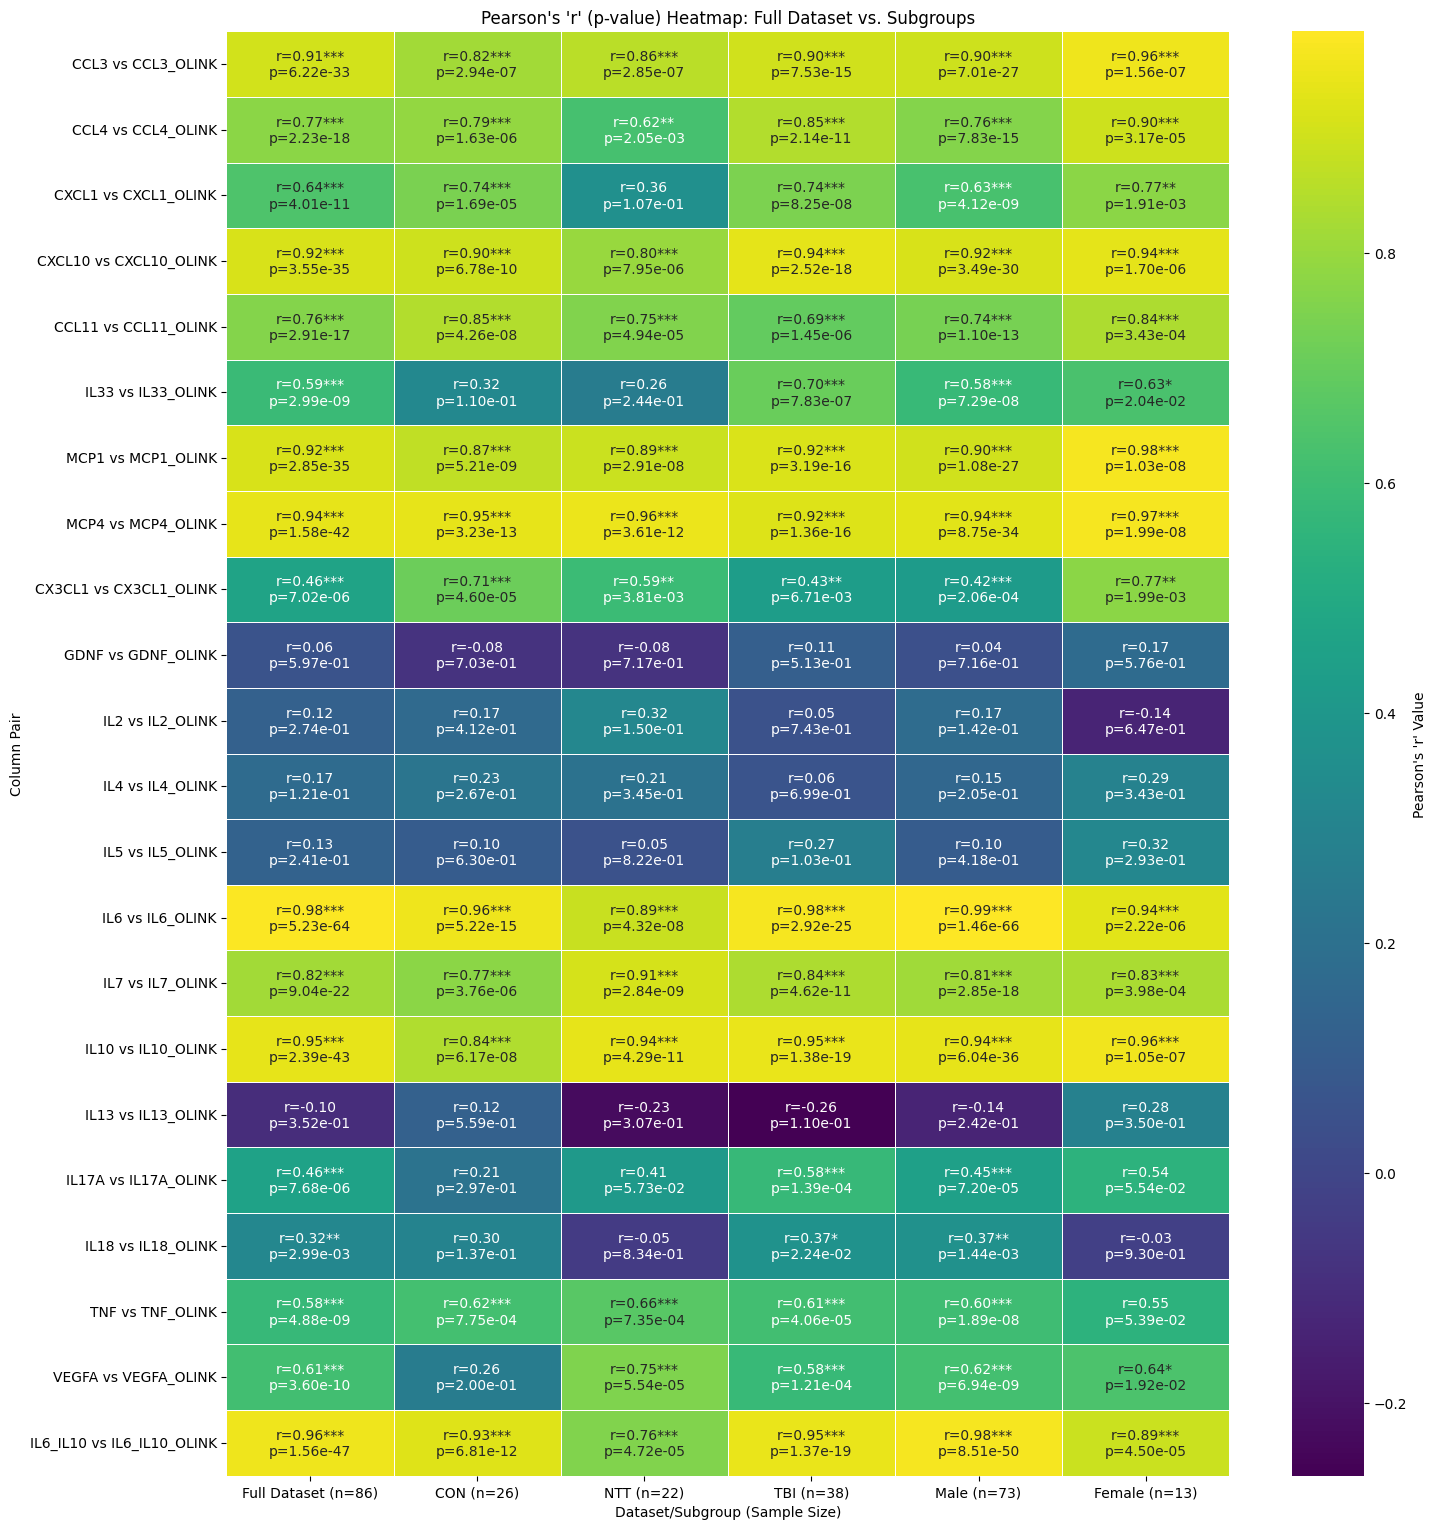

In [ ]:
# --- 4. Generate the Heatmap ---

# Create new x-axis labels with (n=sample_size)
new_xticklabels = []
for col_name in r_heatmap_data.columns:
    # Assuming n is consistent for a given group across column pairs
    total_n_for_group = n_heatmap_data[col_name].iloc[0] if not n_heatmap_data[col_name].empty else 0
    new_xticklabels.append(f"{col_name} (n={int(total_n_for_group)})")

plt.figure(figsize=(15, len(r_heatmap_data) * 0.7))
sns.heatmap(r_heatmap_data,
            annot=annotations,
            fmt='', # Use empty format string because annotations are pre-formatted
            cmap='viridis',
            linewidths=.5,
            cbar_kws={'label': "Pearson's 'r' Value"},
            xticklabels=new_xticklabels) # Use custom x-axis labels

plt.title("Pearson's 'r' (p-value) Heatmap: Full Dataset vs. Subgroups")
plt.xlabel('Dataset/Subgroup (Sample Size)')
plt.ylabel('Column Pair')
plt.yticks(rotation=0) # Keep y-labels horizontal for better readability
plt.tight_layout()
plt.show()


In [ ]:
import sys
!{sys.executable} -m pip install mcc

### Passing-Bablok Regression Analysis

Now, let's perform Passing-Bablok regression for each 'OLINK' and 'Counterpart' column pair across the full dataset and the subgroups. This method provides estimates for the intercept (constant bias) and slope (proportional bias) and their confidence intervals, which are valuable for method comparison.


In [ ]:
from mcc import compare
import pandas as pd
import numpy as np

def calculate_passing_bablok(col1, col2):
    """Calculates Passing-Bablok regression parameters."""
    # Drop NaN values for calculation
    common_indices = col1.dropna().index.intersection(col2.dropna().index)
    if len(common_indices) < 5: # Passing-Bablok often requires a reasonable number of points
        return np.nan, np.nan, (np.nan, np.nan), (np.nan, np.nan)

    col1 = col1.loc[common_indices]
    col2 = col2.loc[common_indices]

    try:
        pb = compare.passing_bablok(col1, col2)
        return pb.intercept, pb.slope, pb.ci_intercept, pb.ci_slope
    except Exception as e:
        # print(f"Error calculating PB for pair: {e}")
        return np.nan, np.nan, (np.nan, np.nan), (np.nan, np.nan)


# Prepare full dataset Passing-Bablok results
full_pb_results = []
for olink_col in olink_columns_master:
    base_name = olink_col.replace('_OLINK', '')
    if base_name in df.columns:
        col1_numeric = pd.to_numeric(df[base_name], errors='coerce') # X-axis: reference method (non-OLINK)
        col2_numeric = pd.to_numeric(df[olink_col], errors='coerce')  # Y-axis: test method (OLINK)
        intercept, slope, ci_intercept, ci_slope = calculate_passing_bablok(col1_numeric, col2_numeric)
        if not pd.isna(intercept):
            full_pb_results.append({
                'Column Pair': f'{base_name} vs {olink_col}',
                'Full Dataset Intercept': intercept,
                'Full Dataset Slope': slope,
                'Full Dataset Intercept CI': f"[{ci_intercept[0]:.2f}, {ci_intercept[1]:.2f}]",
                'Full Dataset Slope CI': f"[{ci_slope[0]:.2f}, {ci_slope[1]:.2f}]"
            })
full_pb_df = pd.DataFrame(full_pb_results)

# Prepare subgroup Passing-Bablok results
all_subgroup_pb = {}

# Process existing 'GROUP' categories
group_categories = ['CON', 'NTT', 'TBI']
for group_name in group_categories:
    df_subgroup = df[df['GROUP'] == group_name].copy()

    if df_subgroup.empty:
        print(f"No data found for group {group_name}. Skipping PB calculation.")
        continue

    subgroup_pb_results = []
    for olink_col in olink_columns_master:
        base_name = olink_col.replace('_OLINK', '')
        if base_name in df_subgroup.columns:
            col1_numeric = pd.to_numeric(df_subgroup[base_name], errors='coerce')
            col2_numeric = pd.to_numeric(df_subgroup[olink_col], errors='coerce')
            intercept, slope, ci_intercept, ci_slope = calculate_passing_bablok(col1_numeric, col2_numeric)
            if not pd.isna(intercept):
                subgroup_pb_results.append({
                    'Column Pair': f'{base_name} vs {olink_col}',
                    f'{group_name} Intercept': intercept,
                    f'{group_name} Slope': slope,
                    f'{group_name} Intercept CI': f"[{ci_intercept[0]:.2f}, {ci_intercept[1]:.2f}]",
                    f'{group_name} Slope CI': f"[{ci_slope[0]:.2f}, {ci_slope[1]:.2f}]"
                })

    if subgroup_pb_results:
        subgroup_df = pd.DataFrame(subgroup_pb_results)
        all_subgroup_pb[group_name] = subgroup_df

# Process 'Male' subgroup
df_male_pb = df[df['male'] == 1].copy()
if not df_male_pb.empty:
    pb_results_male = []
    for olink_col in olink_columns_master:
        base_name = olink_col.replace('_OLINK', '')
        if base_name in df_male_pb.columns:
            col1_numeric = pd.to_numeric(df_male_pb[base_name], errors='coerce')
            col2_numeric = pd.to_numeric(df_male_pb[olink_col], errors='coerce')
            intercept, slope, ci_intercept, ci_slope = calculate_passing_bablok(col1_numeric, col2_numeric)
            if not pd.isna(intercept):
                pb_results_male.append({
                    'Column Pair': f'{base_name} vs {olink_col}',
                    'Male Intercept': intercept,
                    'Male Slope': slope,
                    'Male Intercept CI': f"[{ci_intercept[0]:.2f}, {ci_intercept[1]:.2f}]",
                    'Male Slope CI': f"[{ci_slope[0]:.2f}, {ci_slope[1]:.2f}]"
                })
    if pb_results_male:
        male_pb_df = pd.DataFrame(pb_results_male)
        all_subgroup_pb['Male'] = male_pb_df

# Process 'Female' subgroup
df_female_pb = df[df['female'] == 1].copy()
if not df_female_pb.empty:
    pb_results_female = []
    for olink_col in olink_columns_master:
        base_name = olink_col.replace('_OLINK', '')
        if base_name in df_female_pb.columns:
            col1_numeric = pd.to_numeric(df_female_pb[base_name], errors='coerce')
            col2_numeric = pd.to_numeric(df_female_pb[olink_col], errors='coerce')
            intercept, slope, ci_intercept, ci_slope = calculate_passing_bablok(col1_numeric, col2_numeric)
            if not pd.isna(intercept):
                pb_results_female.append({
                    'Column Pair': f'{base_name} vs {olink_col}',
                    'Female Intercept': intercept,
                    'Female Slope': slope,
                    'Female Intercept CI': f"[{ci_intercept[0]:.2f}, {ci_intercept[1]:.2f}]",
                    'Female Slope CI': f"[{ci_slope[0]:.2f}, {ci_slope[1]:.2f}]"
                })
    if pb_results_female:
        female_pb_df = pd.DataFrame(pb_results_female)
        all_subgroup_pb['Female'] = female_pb_df

# Merge all Passing-Bablok DataFrames
merged_pb_df = full_pb_df
for group_name, subgroup_df in all_subgroup_pb.items():
    merged_pb_df = pd.merge(merged_pb_df, subgroup_df, on='Column Pair', how='left')

# Display the merged Passing-Bablok results
print("Passing-Bablok Regression Results: Intercept, Slope, and 95% Confidence Intervals")
display(merged_pb_df.set_index('Column Pair').sort_values(by='Full Dataset Slope', ascending=False))